# Multi-epoch galaxy populations

It is possible to seemlessly create self-consistent mult-epoch galaxy populations. 

This works by defining the characteristics (galaxy stellar mass function, star formation histories) at the final epoch.

A requirement here is the need to provide a function that describes, as a function of the redshift, and final mass, the number of descendents. Using this each projected galaxy is split into several descendents. 

In [6]:
from astropy.cosmology import Planck18 as cosmo
import numpy as np
from synthesizer.parametric import SFH, ZDist
from synthesizer.grid import Grid
from synthpop.distribution_functions import Schechter
from synthpop.galaxy_population import MultiEpochGalaxyPopulation
from unyt import yr, Myr, Msun, Gyr, unyt_quantity, Mpc, dimensionless, deg, sr, arcminute


In [7]:
# Define the volume of the galaxy population
volume = 1E5 * Mpc**3

# Define the galaxy stellar mass function (GSMF) using a Schechter function
x_star = 10**10.745 * Msun     
phi_star = 10**(-2.437) * Mpc**-3  
alpha = -1.465
gsmf = Schechter(x_star=x_star, alpha=alpha, phi_star=phi_star)

In [8]:
# load grid
grid = Grid("test_grid")

In [9]:
# Define the star formation and metallicity histories for the galaxies in the population

# Define a delta function for metallicity
metal_dist_function = ZDist.DeltaConstant

metal_dist_parameters = {
    "log10metallicity": -2.5
}

# Define a constant star formation history (SFH)
sfh_function = SFH.Constant

sfh_parameters = {
    "max_age": 10000 * Myr
}

0.0 Myr
7935.542002084362 Myr
10510.05491751732 Myr
11643.13146468227 Myr
12249.273396430466 Myr
12616.179261012536 Myr
12857.620352244136 Myr
----------
SUMMARY OF GALAXY POPULATION
Volume: 1.00e+05 Mpc**3
Redshifts: [0. 1. 2. 3. 4. 5. 6.]
----------

3884 (np.float64(1000668119.1947907), np.float64(99728860646.18074))
3901 (np.float64(421162784.26028055), np.float64(40344471134.12117))
3854 (np.float64(232651176.56798762), np.float64(22023775935.820934))
3871 (np.float64(154502769.394752), np.float64(14197326548.684378))
3882 (np.float64(116791906.73534027), np.float64(11621463392.798248))
3947 (np.float64(93958444.76880573), np.float64(9381022220.830471))
3899 (np.float64(78885448.9863578), np.float64(7788241359.415311))


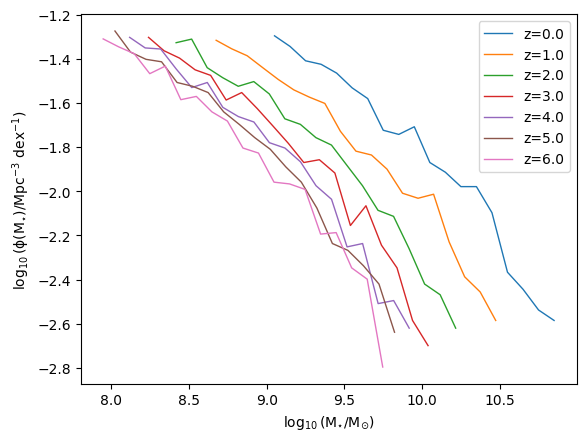

In [10]:

# Instantiate the galaxy population
megp = MultiEpochGalaxyPopulation(
    galaxy_stellar_mass_function=gsmf, 
    minimum_stellar_mass=1E9*Msun, 
    maximum_stellar_mass=1E11*Msun, 
    volume=volume,
    sfh_function=sfh_function,
    sfh_parameters=sfh_parameters,
    metal_dist_function=metal_dist_function,
    metal_dist_parameters=metal_dist_parameters,
    grid=grid,
    cosmology=cosmo,
    redshifts=np.arange(0.0, 7.0, 1.0),
    random_seed=42,
    same_galaxies_across_epochs=False,
    )

print(megp)

megp.plot_stellar_mass_function()
